## Model Evaluation

Covers:

- ROC AUC y PR AUC
- ROC curve y Precision-Recall curve
- Calibration curve
- Score distribution por clase
- Confusion matrix al threshold óptimo (F1)
- SHAP feature importance (TreeExplainer)
- SHAP summary plot (beeswarm)
- AUC por período (estabilidad temporal)

In [54]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import yaml
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    auc,
    roc_auc_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from pathlib import Path
import sys
import optuna
from optuna.samplers import TPESampler
import shap
import dagshub

In [6]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.transformers import MissingIndicatorTransformer

In [7]:
best_params_logistic = joblib.load('../artifacts/model/logistic_final_params.pkl')
best_model_logistic = joblib.load('../artifacts/model/logistic_model.pkl')

X_test = pd.read_parquet('../data/features/X_test_woe.parquet')
y_test = pd.read_parquet('../data/features/y_test_woe.parquet')

In [8]:
test_prediction = best_model_logistic.predict(X_test)
test_proba = best_model_logistic.predict_proba(X_test)[:, 1]

test_proba_negatives = best_model_logistic.predict_proba(X_test)[:, 0]
test_proba_positives = best_model_logistic.predict_proba(X_test)[:, 1]

In [9]:
accuracy_score(y_test, test_prediction)

0.987041511091588

### Curva ROC

AUC Score: 0.9920812102332512


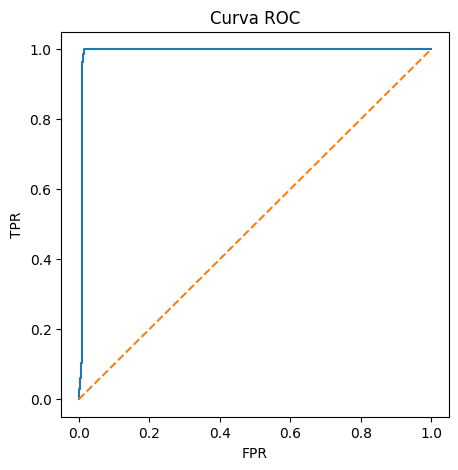

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, test_proba)
auc_score = roc_auc_score(y_test, test_proba)

print(f'AUC Score: {auc_score}')
fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.plot(
    fpr,
    tpr
)

ax.set_title('Curva ROC')
ax.set_ylabel('TPR')
ax.set_xlabel('FPR')
ax.plot([0,1],[0,1], linestyle='--')
plt.show()


### PR Curve

Prevalencia del dataset test: 5.24%
PR AUC: 0.72


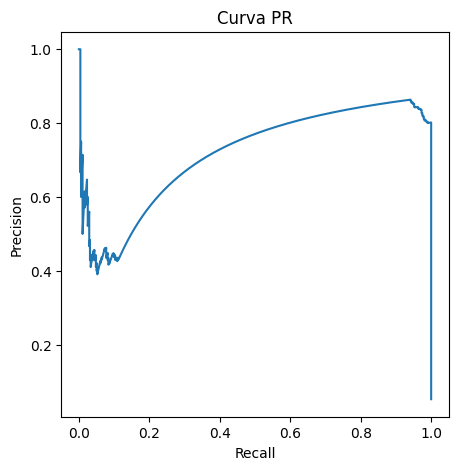

In [11]:
precision, recall, threshold = precision_recall_curve(y_test, test_proba)
pr_auc = auc(recall, precision)
prevalencia = y_test.mean().iloc[0]

print(f'Prevalencia del dataset test: {round((prevalencia)*100, 2)}%')
print(f'PR AUC: {round(pr_auc, 2)}')


fig, ax = plt.subplots(1, 1, figsize =(5,5))
ax.plot(
    recall,
    precision
)
ax.set_title('Curva PR')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')
plt.show()


### Class Distributions

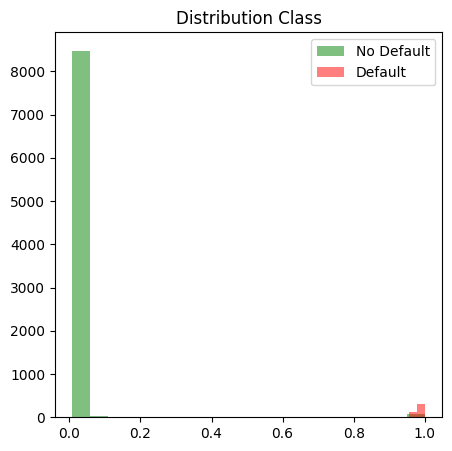

In [12]:
fig, ax = plt.subplots(1, 1, figsize = (5,5))

ax.hist(
    x= test_proba_positives[y_test.squeeze()== 0],
    bins= 20,
    label= 'No Default',
    alpha = 0.5, 
    color= 'green'
)

ax.hist(
    x= test_proba_positives[y_test.squeeze() == 1],
    bins= 20,
    label= 'Default',
    alpha = 0.5, 
    color= 'red'
)

ax.legend()
ax.set_title('Distribution Class')
plt.show()

### Threshold Tunning

Optimizar el F1 score para hallar el threshold óptimo (asumiendo igual valor entre FN y FP)
Si hubiera información de negocio se optimizaría en base a ello

In [13]:
def f1score(precision, recall):
    f1 = (2*precision * recall) / (precision + recall)
    return f1

f1 = f1score(precision, recall)
f1

array([0.09955129, 0.09956168, 0.09957207, ..., 0.00835073, 0.0041841 ,
       0.        ], shape=(9107,))

In [14]:
t = np.argmax(f1score(precision, recall))
print(precision[t])
print(recall[t])
print(threshold[t])


0.8634615384615385
0.9412997903563941
0.9429566902289399


Prevalencia del dataset test: 5.24%
PR AUC: 0.72


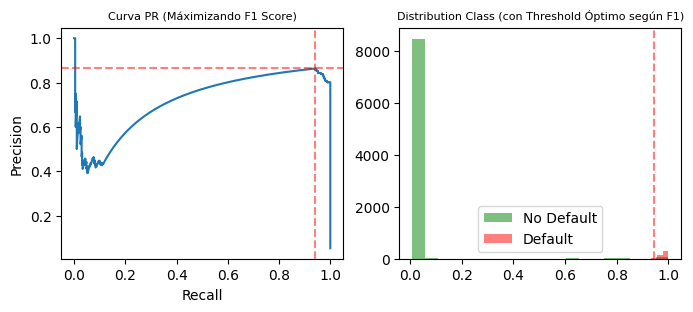

In [15]:
precision, recall, threshold = precision_recall_curve(y_test, test_proba)
pr_auc = auc(recall, precision)
prevalencia = y_test.mean().iloc[0]

print(f'Prevalencia del dataset test: {round((prevalencia)*100, 2)}%')
print(f'PR AUC: {round(pr_auc, 2)}')


fig, ax = plt.subplots(ncols= 2, nrows= 1, figsize =(8,3))

ax[0].plot(
    recall,
    precision
)
ax[0].set_title('Curva PR (Máximizando F1 Score)', fontsize = 8)
ax[0].axhline(precision[t], color = 'red', linestyle = '--', alpha = 0.5)
ax[0].axvline(recall[t], color = 'red', linestyle = '--', alpha = 0.5)
ax[0].set_ylabel('Precision')
ax[0].set_xlabel('Recall')

ax[1].hist(
    x= test_proba_positives[y_test.squeeze()== 0],
    bins= 20,
    label= 'No Default',
    alpha = 0.5, 
    color= 'green'
)

ax[1].hist(
    x= test_proba_positives[y_test.squeeze() == 1],
    bins= 20,
    label= 'Default',
    alpha = 0.5, 
    color= 'red'
)

ax[1].legend()
ax[1].set_title('Distribution Class (con Threshold Óptimo según F1)',  fontsize = 8)
ax[1].axvline(threshold[t], color = 'red', alpha = 0.5, linestyle = '--')

plt.show()



In [59]:
## Guardar el Threshold Óptimo según F1 Score
best_threshold = {
    'threshold': threshold[t]
}

with open('../artifacts/metrics/best_threshold.json', 'w') as f:
    json.dump(best_threshold, f, indent= 4)

### Calibration Model

In [16]:
df_calibration = pd.DataFrame({
    'score': test_proba,
    'target': y_test.squeeze()
})

df_calibration['bins'] = pd.cut(
    df_calibration['score'],
    bins= 5,
)

df_calibration

agg_calibration = df_calibration.groupby(
    ['bins']
).agg(
    target_mean = ('target', 'mean'),
    score_mean = ('score', 'mean'),
    n_obs = ('target', 'count')
).reset_index(level= 0, drop= False)

print(agg_calibration)

               bins  target_mean  score_mean  n_obs
0  (0.00755, 0.207]     0.000000    0.021747   8511
1    (0.405, 0.603]     0.714286    0.583419      7
2    (0.603, 0.802]     0.352941    0.704664     51
3      (0.802, 1.0]     0.845438    0.977171    537


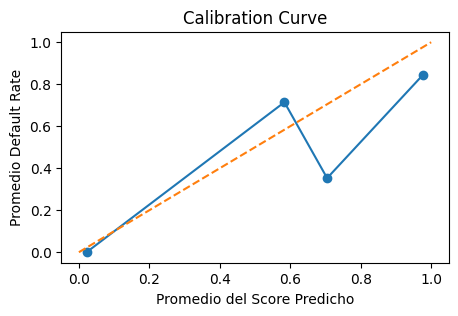

In [17]:
fig, ax = plt.subplots(1, 1, figsize = (5, 3))
ax.plot(
    agg_calibration['score_mean'],
    agg_calibration['target_mean'],
    marker = 'o'
)

ax.plot(
    [0, 1],
    [0, 1],
    '--'
)
ax.set_title('Calibration Curve')
ax.set_ylabel('Promedio Default Rate')
ax.set_xlabel('Promedio del Score Predicho')
plt.show()

### Confusion Matrix Operacional

In [18]:
test_proba_threshold = np.where(test_proba >= threshold[t], 1, 0)
test_proba_threshold

array([0, 0, 0, ..., 0, 0, 0], shape=(9106,))

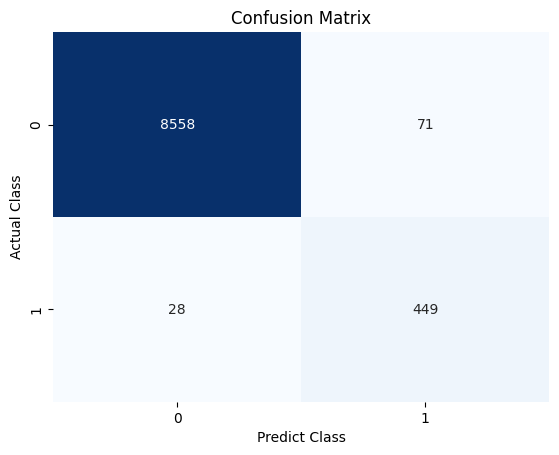

In [19]:
cm = confusion_matrix(y_true= y_test, y_pred= test_proba_threshold)

sns.heatmap(
    cm,
    annot= True,
    fmt= 'd',
    cmap= 'Blues',
    cbar= False
)

plt.title('Confusion Matrix')
plt.xlabel('Predict Class')
plt.ylabel('Actual Class')
plt.show()

### Interpretación con SHAP

In [20]:
best_model_logistic.named_steps

{'preprocessor': Pipeline(steps=[('missing_indicator',
                  MissingIndicatorTransformer(columns=['no_of_children'])),
                 ('column_transform',
                  ColumnTransformer(transformers=[('num_median_logtrans',
                                                   Pipeline(steps=[('imputer_median',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('log_transformation',
                                                                    FunctionTransformer(feature_names_out='one-to-one',
                                                                                        func=<ufunc 'log1p'>)),
                                                                   ('standar_scaler',...
                                                                                  sparse_output=False))]),
                                                  

In [73]:
best_model_logistic.named_steps

preprocessor = best_model_logistic.named_steps['preprocessor']
model = best_model_logistic.named_steps['model']

missing_indicator = preprocessor.named_steps['missing_indicator']
column_transform = preprocessor.named_steps['column_transform']

X_train_woe = pd.read_parquet('../data/features/X_train_woe.parquet')
X_test_woe = pd.read_parquet('../data/features/X_test_woe.parquet')

# Aplicar primero missing indicator
X_train_apply_missing = missing_indicator.transform(X_train_woe)
X_test_apply_missing = missing_indicator.transform(X_test_woe)

# Aplicar el column transform
X_train_transformed = column_transform.transform(X_train_apply_missing)
X_test_transformed = column_transform.transform(X_test_apply_missing)

# Obtener los nombres finales
features_names = column_transform.get_feature_names_out()

joblib.dump(features_names, '../artifacts/metadata/features_names.pkl')


['../artifacts/metadata/features_names.pkl']

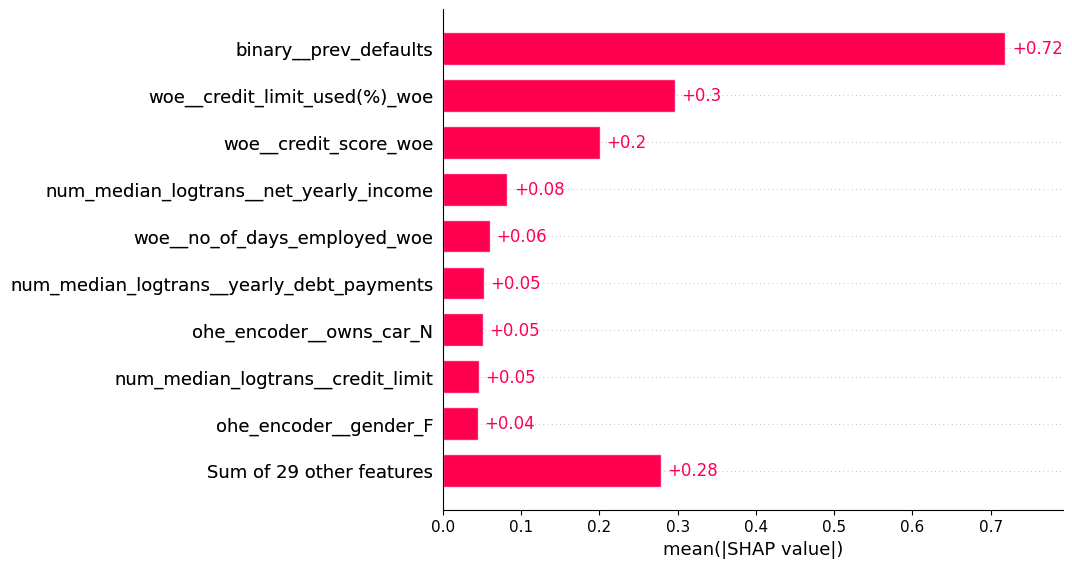

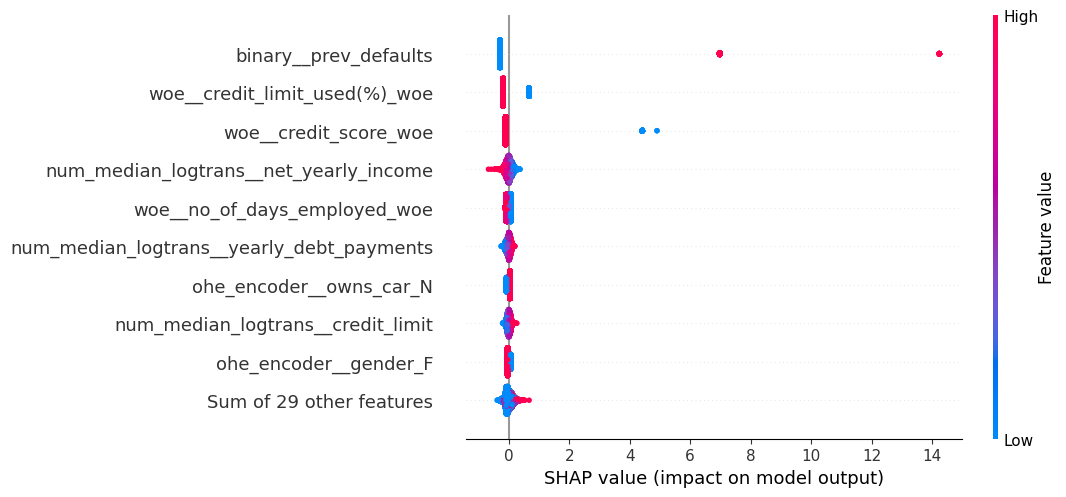

In [75]:
# Armar el dataframe para SHAP (Sería mejor guardar como artefacto el train y 
# test data ya transformados para omitir este paso)

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns= features_names,
    index= X_train_woe.index
)

X_train_shap_sample = X_train_shap.sample(
    n= 1000,
    random_state = 42
)

X_train_shap_sample.to_parquet(
    '../artifacts/interpretabilidad/shap_background.parquet'
)


X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns= features_names,
    index= X_test_woe.index
)

explainer = shap.Explainer(
    model,
    X_train_shap
)

shap_values = explainer(X_test_shap)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

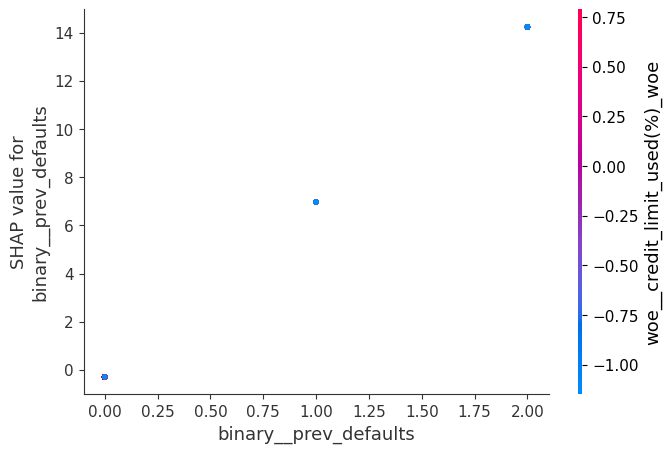

In [23]:
shap.dependence_plot(
    "binary__prev_defaults",
    shap_values.values,
    X_test_shap
)

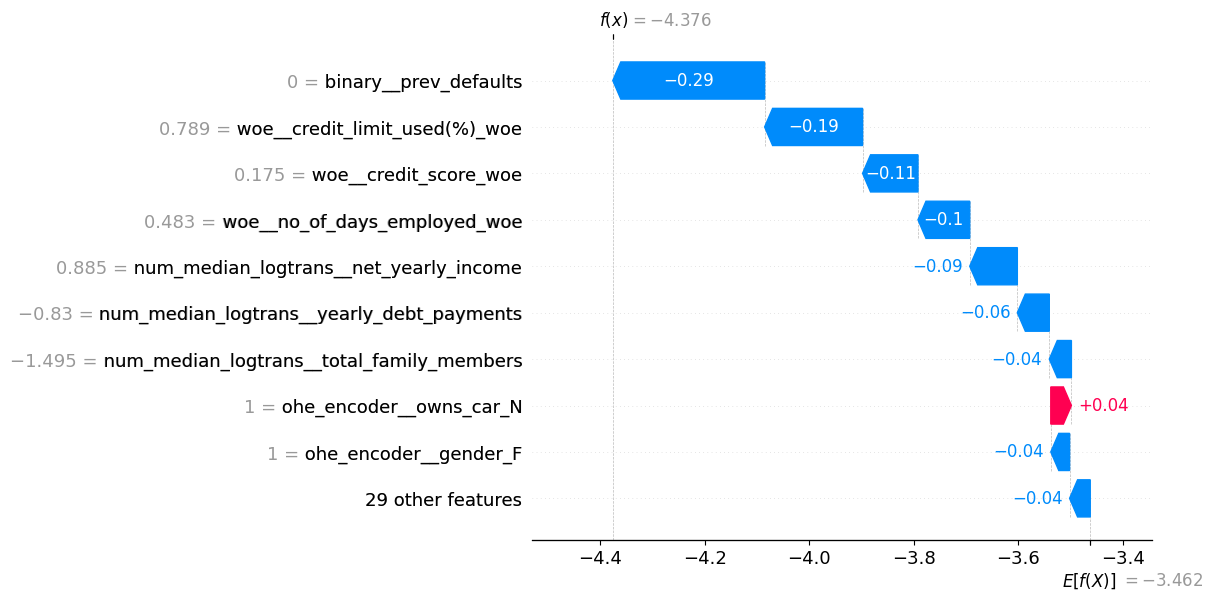

In [24]:
shap.plots.waterfall(
    shap_values[0]
)

### Guardar Artefactos con MLFLOW

In [2]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-riesgo-crediticio', mlflow=True)

Accessing as davidrodriguez2712

Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-riesgo-crediticio"

Repository davidrodriguez2712/proyecto-3-riesgo-crediticio initialized!

In [3]:
mlflow.set_tracking_uri('https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow')


In [4]:
mlflow.set_experiment(experiment_name='Proyecto_3_riesgo_credito')

<Experiment: artifact_location='mlflow-artifacts:/a6c5ecb911f8453daf1b24b248c6b22c', creation_time=1777748161120, experiment_id='2', last_update_time=1777748161120, lifecycle_stage='active', name='Proyecto_3_riesgo_credito', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

AUC Score: 0.9920812102332512


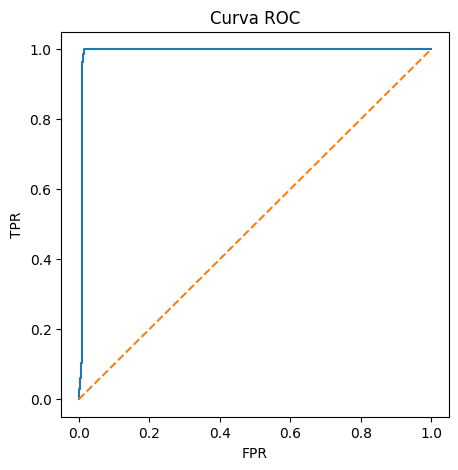

Prevalencia del dataset test: 5.24%
PR AUC: 0.72


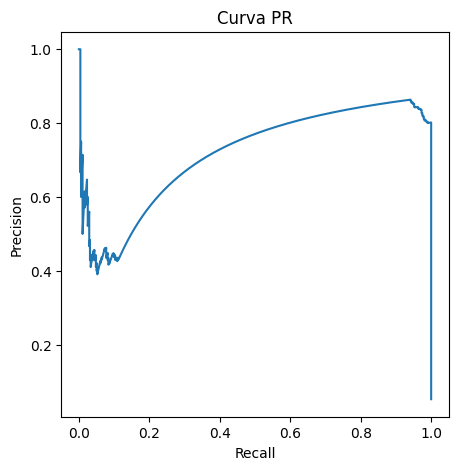

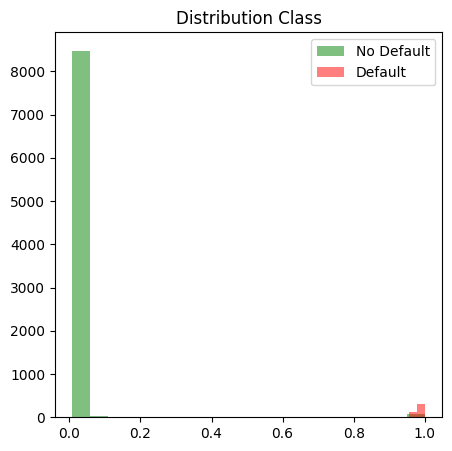

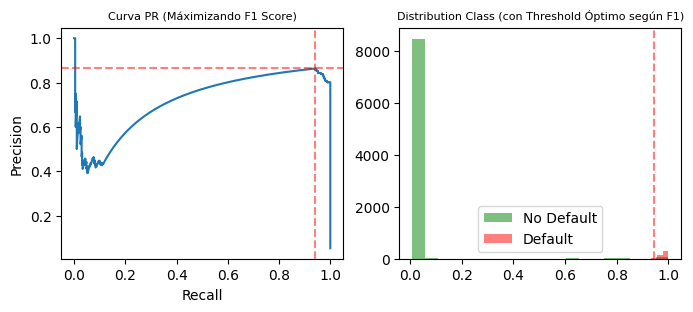

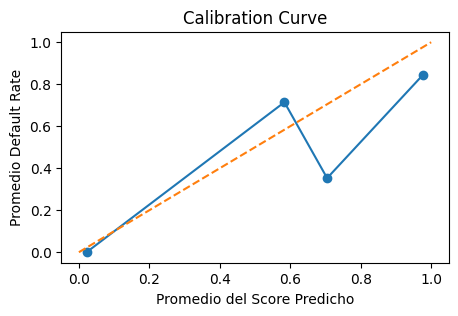

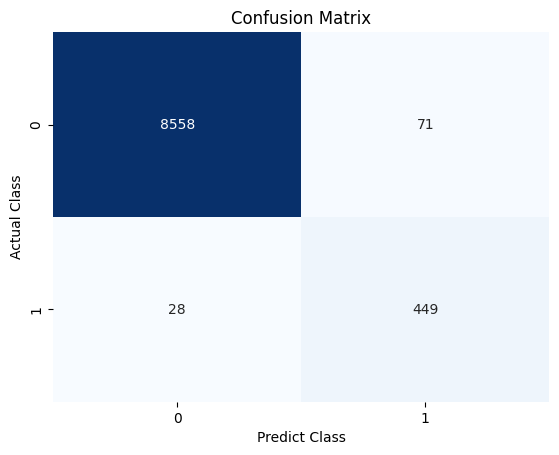

🏃 View run 04_model_evaluation at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2/runs/2a3f31a6a83a493e8acbe1a533542169
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2


In [31]:
with mlflow.start_run(run_name='04_model_evaluation') as run:
    
    ## ROC CURVE
    fpr, tpr, thresholds = roc_curve(y_test, test_proba)
    auc_score = roc_auc_score(y_test, test_proba)

    print(f'AUC Score: {auc_score}')
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    ax.plot(
        fpr,
        tpr
    )

    ax.set_title('Curva ROC')
    ax.set_ylabel('TPR')
    ax.set_xlabel('FPR')
    ax.plot([0,1],[0,1], linestyle='--')
    fig.savefig('../reports/figures/model_evaluation/curva_roc.png')
    mlflow.log_figure(fig, 'curva_roc.png')
    plt.show()
    plt.close(fig)
    
    ## PR CURVE
    precision, recall, threshold = precision_recall_curve(y_test, test_proba)
    pr_auc = auc(recall, precision)
    prevalencia = y_test.mean().iloc[0]

    print(f'Prevalencia del dataset test: {round((prevalencia)*100, 2)}%')
    print(f'PR AUC: {round(pr_auc, 2)}')


    fig, ax = plt.subplots(1, 1, figsize =(5,5))
    ax.plot(
        recall,
        precision
    )
    ax.set_title('Curva PR')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    fig.savefig('../reports/figures/model_evaluation/curva_pr.png')
    mlflow.log_figure(fig, 'curva_pr.png')
    plt.show()
    plt.close(fig)

    ## Class Distribution
    fig, ax = plt.subplots(1, 1, figsize = (5,5))

    ax.hist(
        x= test_proba_positives[y_test.squeeze()== 0],
        bins= 20,
        label= 'No Default',
        alpha = 0.5, 
        color= 'green'
    )

    ax.hist(
        x= test_proba_positives[y_test.squeeze() == 1],
        bins= 20,
        label= 'Default',
        alpha = 0.5, 
        color= 'red'
    )

    ax.legend()
    ax.set_title('Distribution Class')
    
    fig.savefig('../reports/figures/model_evaluation/class_distribution.png')
    mlflow.log_figure(fig, 'class_distribution.png')
    plt.show()
    plt.close(fig)

    ## Threshold Tunning
    fig, ax = plt.subplots(ncols= 2, nrows= 1, figsize =(8,3))

    ax[0].plot(
        recall,
        precision
    )
    ax[0].set_title('Curva PR (Máximizando F1 Score)', fontsize = 8)
    ax[0].axhline(precision[t], color = 'red', linestyle = '--', alpha = 0.5)
    ax[0].axvline(recall[t], color = 'red', linestyle = '--', alpha = 0.5)
    ax[0].set_ylabel('Precision')
    ax[0].set_xlabel('Recall')

    ax[1].hist(
        x= test_proba_positives[y_test.squeeze()== 0],
        bins= 20,
        label= 'No Default',
        alpha = 0.5, 
        color= 'green'
    )

    ax[1].hist(
        x= test_proba_positives[y_test.squeeze() == 1],
        bins= 20,
        label= 'Default',
        alpha = 0.5, 
        color= 'red'
    )

    ax[1].legend()
    ax[1].set_title('Distribution Class (con Threshold Óptimo según F1)',  fontsize = 8)
    ax[1].axvline(threshold[t], color = 'red', alpha = 0.5, linestyle = '--')

    fig.savefig('../reports/figures/model_evaluation/threshold_tunning.png')
    mlflow.log_figure(fig, 'threshold_tunning.png')
    plt.show()
    plt.close(fig)

    ## Calibration Curve
    fig, ax = plt.subplots(1, 1, figsize = (5, 3))
    ax.plot(
        agg_calibration['score_mean'],
        agg_calibration['target_mean'],
        marker = 'o'
    )

    ax.plot(
        [0, 1],
        [0, 1],
        '--'
    )
    ax.set_title('Calibration Curve')
    ax.set_ylabel('Promedio Default Rate')
    ax.set_xlabel('Promedio del Score Predicho')
    
    fig.savefig('../reports/figures/model_evaluation/calibration_curve.png')
    mlflow.log_figure(fig, 'calibration_curve.png')
    plt.show()
    plt.close(fig)

    ## Confusion Matrix Operacional

    cm = confusion_matrix(y_true= y_test, y_pred= test_proba_threshold)

    sns.heatmap(
        cm,
        annot= True,
        fmt= 'd',
        cmap= 'Blues',
        cbar= False
    )

    plt.title('Confusion Matrix')
    plt.xlabel('Predict Class')
    plt.ylabel('Actual Class')

    fig.savefig('../reports/figures/model_evaluation/confusion_matrix.png')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()
    plt.close(fig)

    ## SHAP Bar Plot

    shap.plots.bar(shap_values, show= False)
    fig = plt.gcf()

    fig.savefig('../reports/figures/model_evaluation/shap_bar_plot.png')
    mlflow.log_figure(fig, 'shap_bar_plot.png')
    plt.close(fig)

    ## SHAP Beeswarm Plot
    shap.plots.beeswarm(shap_values, show= False)
    fig = plt.gcf()

    fig.savefig('../reports/figures/model_evaluation/shap_beeswarm_plot.png')
    mlflow.log_figure(fig, 'shap_beeswarm_plot.png')
    plt.close(fig)

    ## Predictions Test (Luego del Threshold Tunning - F1 optimizado)

    predictions_df = pd.DataFrame({
        'y_true': y_test.squeeze(),
        'y_score': test_proba,
        'y_pred': test_proba_threshold
    })

    predictions_df.to_parquet('../artifacts/predictions/test_predictions.parquet')

    mlflow.log_artifact('../artifacts/predictions/test_predictions.parquet')

    ## SHAP Values
    joblib.dump(shap_values, '../artifacts/interpretabilidad/shap_values.pkl')
    mlflow.log_artifact('../artifacts/interpretabilidad/shap_values.pkl')
    



### Test Dataset (En nuestra simulación será como el OOT)

In [78]:
best_params_logistic = joblib.load('../artifacts/model/logistic_final_params.pkl')
best_model_logistic = joblib.load('../artifacts/model/logistic_model.pkl')
reglas_woe = joblib.load('../artifacts/encoders/woe_bins.pkl')
df_test_oot = pd.read_csv('../data/raw/test.csv')

In [37]:
with open("../params.yaml") as f:
    parameters = yaml.safe_load(f)

FEATURES = parameters["features"]
MODEL = parameters["model"]

NUMERIC = FEATURES["numeric"]
CATEGORICAL = FEATURES["categorical"]
TARGET = FEATURES["target"]

#### Realizamos primero el proceso de WOE

In [79]:
# 1ra Feature: credit_limit_used(%) -> 0% missings
df_test_oot['credit_limit_used(%)_woe'] = pd.cut(
    x= df_test_oot['credit_limit_used(%)'],
    bins= reglas_woe['credit_limit_used(%)']['bins'],
    labels = reglas_woe['credit_limit_used(%)']['woe_values']
).astype(float)

# 2da Feature: no_of_days_employed -> (1.02% missings)
df_test_oot['no_of_days_employed_woe'] = pd.cut(
    x= df_test_oot['no_of_days_employed'],
    bins= reglas_woe['no_of_days_employed']['bins'],
    labels = reglas_woe['no_of_days_employed']['woe_values']
).astype(float)
df_test_oot.loc[df_test_oot['no_of_days_employed'].isna(), 'no_of_days_employed_woe'] = reglas_woe['no_of_days_employed']['missing_woe']

# 3ra Feature: credit_score -> (0.02% missings)
df_test_oot['credit_score_woe'] = pd.cut(
    x= df_test_oot['credit_score'],
    bins= reglas_woe['credit_score']['bins'],
    labels = reglas_woe['credit_score']['woe_values']
).astype(float)
df_test_oot.loc[df_test_oot['credit_score'].isna(), 'credit_score_woe'] = reglas_woe['credit_score']['missing_woe']


In [80]:
df_test_oot

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,...,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_limit_used(%)_woe,no_of_days_employed_woe,credit_score_woe
0,CST_142525,Siva,52,F,Y,N,0.0,232640.53,998.0,Unknown,...,0.0,14406.73,26524.40,4,779.0,0,0,0.790648,-0.209455,0.202984
1,CST_129215,Scott,48,F,N,N,1.0,284396.79,1338.0,Unknown,...,0.0,57479.99,68998.72,70,806.0,0,0,0.790648,-0.209455,0.202984
2,CST_138443,Victoria,50,F,N,N,1.0,149419.28,1210.0,Unknown,...,0.0,21611.01,25187.80,71,528.0,2,0,0.790648,-0.209455,-2.847129
3,CST_123812,John McCrank,30,F,N,N,1.0,160437.54,503.0,Laborers,...,1.0,28990.76,29179.39,9,815.0,0,0,0.790648,-0.377351,0.202984
4,CST_144450,Martinne,52,M,N,Y,0.0,233480.37,157.0,Laborers,...,1.0,54213.72,82331.82,82,613.0,1,1,-1.139177,-0.377351,0.202984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11378,CST_142412,Solarina,53,F,N,N,0.0,266824.38,3051.0,Sales staff,...,0.0,17791.56,64483.93,74,823.0,0,0,0.790648,-0.023241,0.202984
11379,CST_107967,Jonathan Cable,33,F,NaN,N,0.0,124310.85,365248.0,Unknown,...,0.0,26576.79,29851.73,60,712.0,0,0,0.790648,0.469405,0.202984
11380,CST_134002,Robin,27,M,Y,Y,1.0,364652.81,3431.0,Laborers,...,0.0,28658.55,69336.96,67,674.0,0,0,0.790648,0.373830,0.202984
11381,CST_146856,Lauren,36,F,N,Y,0.0,128769.02,16320.0,Medicine staff,...,0.0,11527.38,26908.03,17,684.0,0,0,0.790648,0.469405,0.202984


In [81]:
## Guardar en Splits (porque todavía no se ha aplicado transformaciones del pipeline)
y_test_oot = df_test_oot['default_in_last_6months']
X_test_oot = df_test_oot.drop('default_in_last_6months', axis = 1)

y_test_oot.to_frame().to_parquet('../data/features/y_test_oot_woe.parquet')
X_test_oot.to_parquet('../data/features/X_test_oot_woe.parquet')

In [82]:
## Considerando el Threshold tunning (Maximizando F1 Score)
proba_test_oot = best_model_logistic.predict_proba(df_test_oot)[:,1]
predictions_test_oot = np.where(proba_test_oot >= threshold[t], 1, 0)
roc_auc_test_oot = roc_auc_score(y_true= df_test_oot[TARGET], y_score= proba_test_oot)

In [83]:
## Métricas Test/OOT
metrics_test_oot = pd.DataFrame({
    'y_true': df_test_oot[TARGET],
    'y_score': proba_test_oot,
    'y_pred': predictions_test_oot
}).to_parquet('../artifacts/predictions/test_oot_predictions.parquet')

In [56]:
## Métricas Operacionales
metrics_test_oot = {
    'auc': roc_auc_test_oot,
    'f1': f1_score(y_true= df_test_oot[TARGET], y_pred= predictions_test_oot),
    'recall': recall_score(y_true= df_test_oot[TARGET], y_pred= predictions_test_oot),
    'accuracy': accuracy_score(y_true= df_test_oot[TARGET], y_pred= predictions_test_oot)
}

with open('../artifacts/metrics/metrics_test_oot.json', 'w') as f:
    json.dump(metrics_test_oot, f, indent= 4)

#### ROC CURVE - TEST/OOT

AUC Score: 0.994513662171339


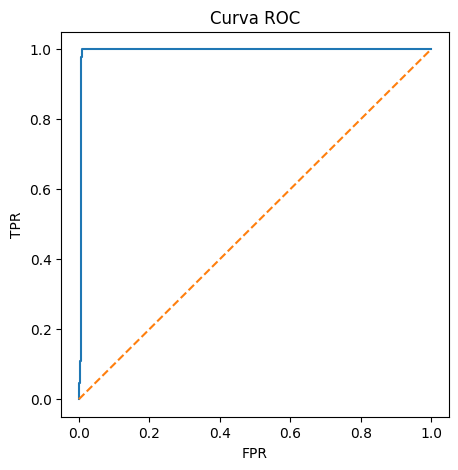

In [84]:
fpr, tpr, thresholds = roc_curve(df_test_oot[TARGET], proba_test_oot)
auc_score = roc_auc_score(df_test_oot[TARGET], proba_test_oot)

print(f'AUC Score: {auc_score}')
fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.plot(
    fpr,
    tpr
)

ax.set_title('Curva ROC')
ax.set_ylabel('TPR')
ax.set_xlabel('FPR')
ax.plot([0,1],[0,1], linestyle='--')
plt.show()

### PR Curve

Prevalencia del dataset test: 4.87%
PR AUC: 0.77


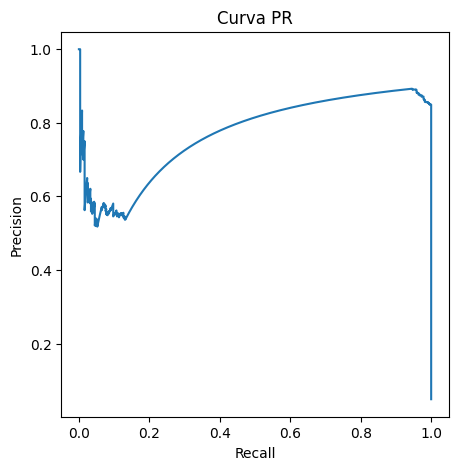

In [86]:
precision, recall, threshold = precision_recall_curve(df_test_oot[TARGET], proba_test_oot)
pr_auc = auc(recall, precision)
prevalencia = df_test_oot[TARGET].mean()

print(f'Prevalencia del dataset test: {round((prevalencia)*100, 2)}%')
print(f'PR AUC: {round(pr_auc, 2)}')


fig, ax = plt.subplots(1, 1, figsize =(5,5))
ax.plot(
    recall,
    precision
)
ax.set_title('Curva PR')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')
plt.show()